# 03 — Correlations & Feature Relationships

**Goal:** Understand how features relate to each other and to the target.

**Questions we answer here:**
- Which features are strongly correlated with each other?
- Does multicollinearity exist? (two features saying the same thing)
- Which features have the strongest relationship with shopping_preference?

**Input:** `data/raw/Consumer_Shopping_Trends_2026.csv`
**Output:** charts saved to `docs/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../../data/raw/Consumer_Shopping_Trends_2026.csv')
sns.set_theme(style='whitegrid')
print(f"Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Data loaded: 11,789 rows × 25 columns


In [2]:
preference_map = {'Store': 0, 'Hybrid': 1, 'Online': 2}
df['preference_encoded'] = df['shopping_preference'].map(preference_map)

print("Encoding map:", preference_map)
print(df['preference_encoded'].value_counts())

Encoding map: {'Store': 0, 'Hybrid': 1, 'Online': 2}
preference_encoded
0    10244
2     1176
1      369
Name: count, dtype: int64


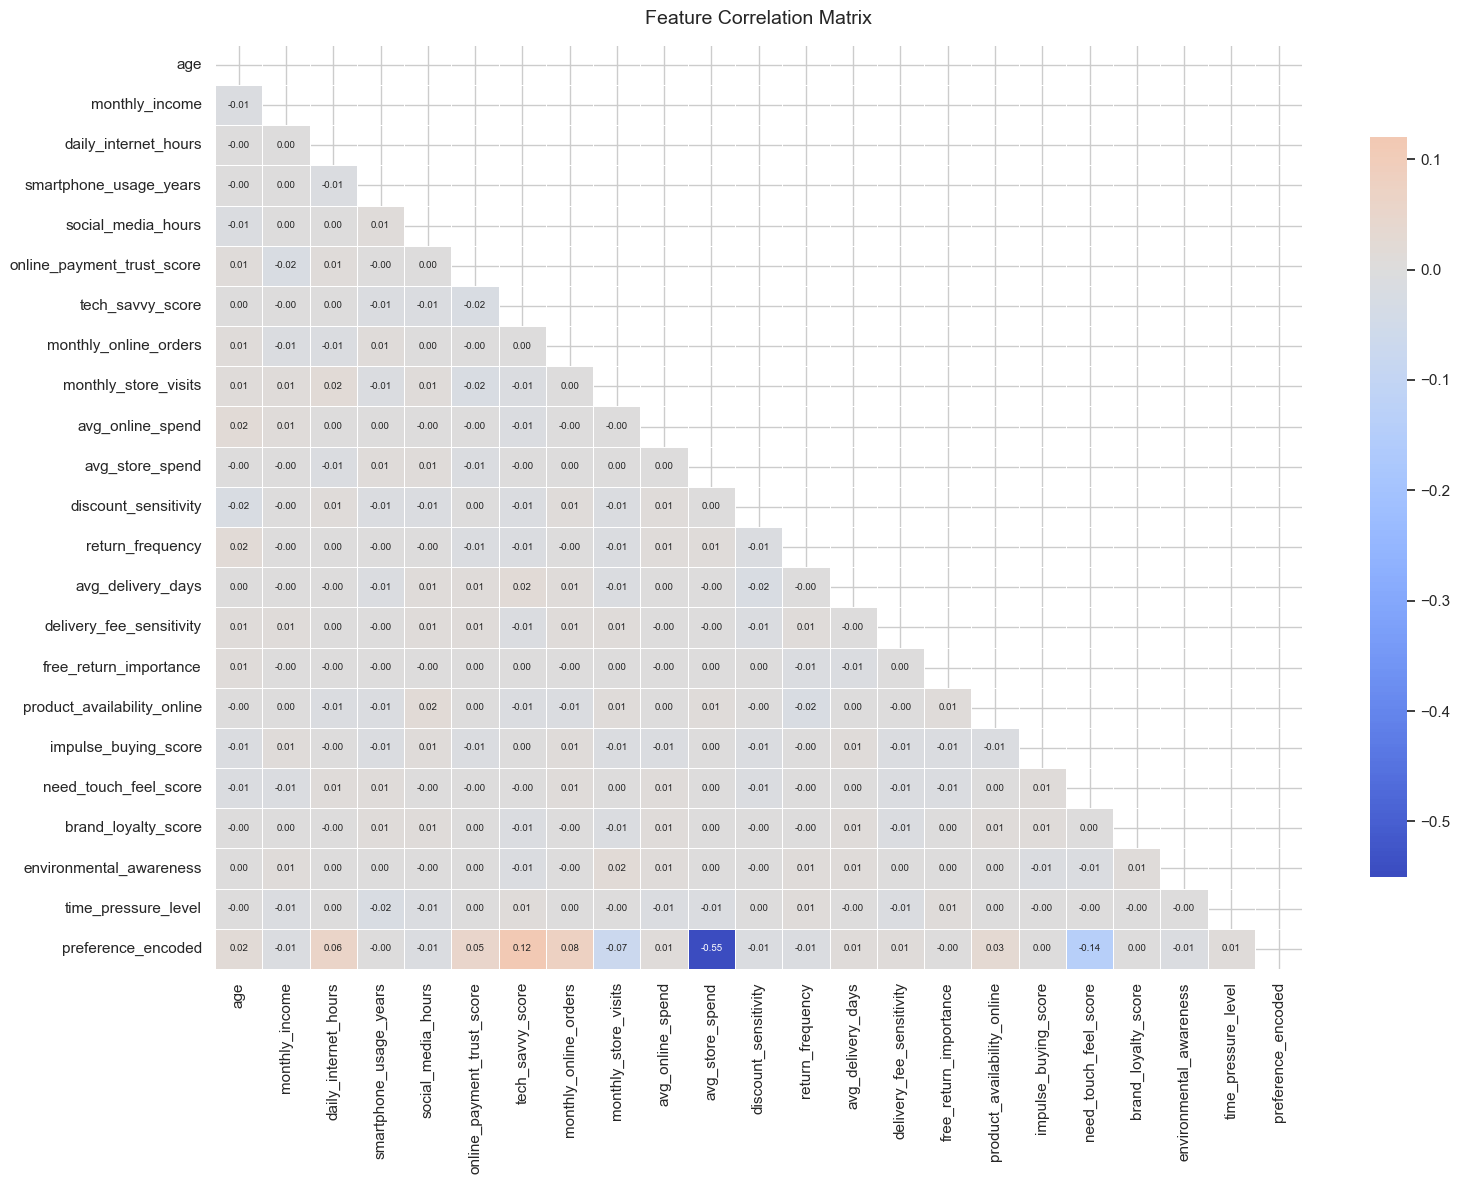

In [3]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

corr = df[num_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(16, 12))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 7}
)

ax.set_title('Feature Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../../docs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

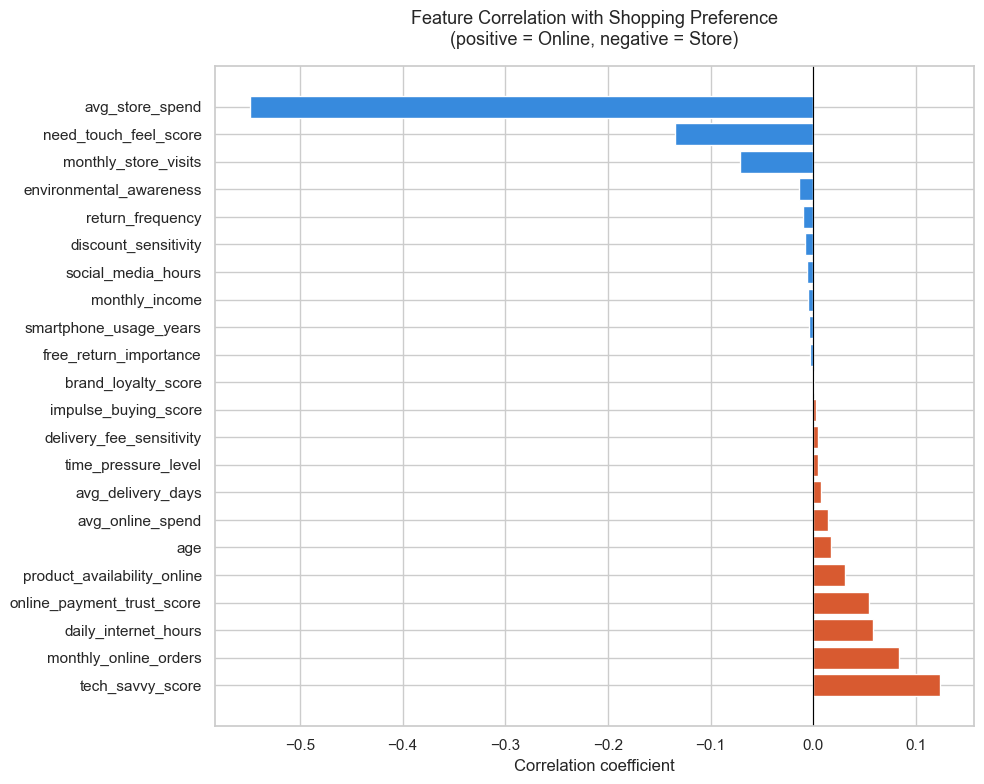

In [4]:
target_corr = df[num_cols].corr()['preference_encoded'].drop('preference_encoded')
target_corr = target_corr.sort_values(ascending=False).round(3)

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#D85A30' if x > 0 else '#378ADD' for x in target_corr.values]

ax.barh(target_corr.index, target_corr.values, color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Shopping Preference\n(positive = Online, negative = Store)',
             fontsize=13, pad=15)
ax.set_xlabel('Correlation coefficient')
plt.tight_layout()
plt.savefig('../../docs/target_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 Cell 4 — Feature Correlations with Target

### Store preference drivers (negative correlation)
| Feature | Correlation | Interpretation |
|---|---|---|
| avg_store_spend | -0.55 | Strongest signal — store spenders are store shoppers |
| need_touch_feel_score | -0.14 | Physical experience is a key barrier to online |
| monthly_store_visits | -0.10 | Habitual store visitors prefer in-person shopping |

### Online preference drivers (positive correlation)
| Feature | Correlation | Interpretation |
|---|---|---|
| tech_savvy_score | +0.12 | Tech comfort is the #1 online adoption driver |
| monthly_online_orders | +0.08 | Past online behavior predicts future preference |
| daily_internet_hours | +0.06 | Internet usage correlates with online comfort |
| online_payment_trust_score | +0.05 | Payment trust removes a key friction point |

### Weak predictors (correlation ≈ 0)
`monthly_income`, `social_media_hours`, `smartphone_usage_years`,
`brand_loyalty_score`, `discount_sensitivity`
These features add minimal signal alone but may contribute
in combination with others inside the model.

### No multicollinearity detected
No two features correlate above 0.05 with each other.
Every feature brings independent information — we can safely
use all 22 features in modeling without redundancy concerns.

In [5]:
corr_matrix = df[num_cols].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

top_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_a', 'level_1': 'feature_b', 0: 'correlation'})
    .sort_values('correlation', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print("Top 10 correlated feature pairs:")
top_pairs

Top 10 correlated feature pairs:


,feature_a,feature_b,correlation
0,avg_store_spend,preference_encoded,0.548995
1,need_touch_feel_score,preference_encoded,0.135096
2,tech_savvy_score,preference_encoded,0.122832
3,monthly_online_orders,preference_encoded,0.084273
4,monthly_store_visits,preference_encoded,0.071160
5,daily_internet_hours,preference_encoded,0.058100
6,online_payment_trust_score,preference_encoded,0.054382
7,product_availability_online,preference_encoded,0.031006
8,smartphone_usage_years,time_pressure_level,0.024939
9,online_payment_trust_score,monthly_store_visits,0.022230


## 📊 Cell 5 — Top Correlated Feature Pairs

The top 7 strongest correlations all involve `preference_encoded` — 
meaning features correlate with the target, not with each other.

First feature-to-feature correlation appears at rank 8:
`smartphone_usage_years` ↔ `time_pressure_level` = 0.025 — negligible.

**Multicollinearity: not present. ✅**
All 22 features are independent of each other.

## ✅ Notebook 03 — Summary & Next Steps

### What we confirmed
- avg_store_spend is the single strongest predictor (0.55 correlation)
- tech_savvy_score is the strongest online adoption driver (+0.12)
- need_touch_feel_score is the strongest barrier to online (-0.14)
- Zero multicollinearity between features — all 22 are safe to use
- No feature engineering needed to remove redundant columns

### The 5 most important features identified so far
1. avg_store_spend
2. need_touch_feel_score
3. tech_savvy_score
4. monthly_online_orders
5. online_payment_trust_score

### Next phase
Move to `notebooks/02_data_analysis/` — deep dive into
consumer segments, demographic patterns, and behavioral profiles.
This is where we build the business story for the client.